<table align="left">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/AbdelMahm/FSR/blob/master/IDDLO-29-20/Notebooks/Logistic_Regression.ipynb"><img src="https://colab.research.google.com/img/colab_favicon_256px.png" />Run in Google Colab</a>
  </td>
</table>

# Logistic Regression

In [ ]:
import sys
import urllib.request
import os

import pandas as pd
import numpy as np

%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt

import sklearn
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
#

## Part1: Logistic Regression
In this part of the exercise, you will build a logistic regression model to predict whether a student gets admitted into a university.
Suppose that you are the administrator of a university department and you want to determine each applicant's chance of admission based on their results on two exams. You have historical data from previous applicants that you can use as a training set for logistic regression. For each training example, you have the applicant's scores on two exams and the admissions decision.
Your task is to build a classification model that estimates an applicant's probability of admission based the scores from those two exams.

### Visualizing the data
Before starting to implement any learning algorithm, it is always good to visualize the data if possible. In the first part, the code will load the data and display it on a 2-dimensional plot where the axes are the two exam scores, and the positive and negative examples are shown with different marker colors.

In [ ]:
import urllib.request
data_path = os.path.join("datasets", "")
download_path = "https://raw.githubusercontent.com/AbdelMahm/FSR/master/IDDLO-29-20/Notebooks/datasets/"
os.makedirs(data_path, exist_ok=True)
for filename in ("log_reg_data1.csv", "log_reg_data2.csv"):
    print("Downloading", filename)
    url = download_path + filename
    urllib.request.urlretrieve(url, data_path + filename)

In [ ]:
#load data
data_exam = pd.read_csv(data_path + '/log_reg_data1.csv')
data_exam.head()

,studentId,score1,score2,admitted
0,1,34.623660,78.024693,0
1,2,30.286711,43.894998,0
2,3,35.847409,72.902198,0
3,4,60.182599,86.308552,1
4,5,79.032736,75.344376,1


### Get the parameters of the model

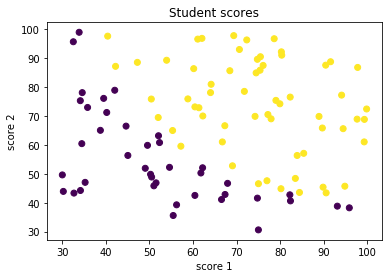

In [ ]:
X = np.c_[data_exam[["score1","score2"]]]
y = np.c_[data_exam["admitted"]]

(m,n) = X.shape

# display all examples
fig = plt.figure()
plt.title('Student scores')
plt.xlabel('score 1')
plt.ylabel('score 2')
plt.scatter(X[:,0],X[:,1], c=y.ravel())
plt.show()

#add a column of 1s to X
#X = np.insert(X, 0, values=1, axis=1)

$w_j$ = clf.coef_, $w_0$ = clf.intercept_

In [ ]:
clf = LogisticRegression(random_state=0, solver='lbfgs', multi_class='multinomial').fit(X, y.ravel())

#print model parameters
print("w0 =", clf.intercept_[0], ", w1 = ", clf.coef_[0][0], ", w2 = ", clf.coef_[0][1])

w0 = -12.553234703609853 , w1 =  0.10289545363158878 , w2 =  0.10051268616820207


### Plot the decision boundary
The decision boundary correspends to the value $y = 0.5$. We can write $x_2$ in terms of $x_1$ by solving the following equation:
$$ 0.5 = w_0 + w_1*x_1 + w_2*x_2 $$

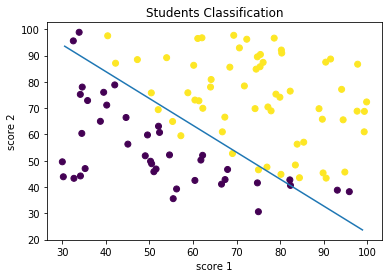

In [ ]:
fig = plt.figure()
ax = plt.axes()
plt.title('Students Classification')
plt.xlabel('score 1')
plt.ylabel('score 2')
plt.scatter(X[:,0], X[:,1], c=y.ravel())

#generate new points to plot a decision boundary line
x1_vals = np.linspace(min(X[:,1]), max(X[:,1]), 1000)
# the boundry is at line at y = 0.5 if y in {0,1} or y = 0 if y in {-1,1},
# sklearn converts y to the range {-1,1}
# So, we can then write x2 in terms of x1 using: (w0 + w1*x1 + w2*x2 = 0)
x2_vals = -(clf.intercept_[0] + clf.coef_[0][0]*x1_vals) / clf.coef_[0][1]

# plot the line
plt.plot(x1_vals, x2_vals)
plt.show()

### Accuracy of the model
the score function measures how well the learned model predicts on a given set.

In [ ]:
#prediction probability of one example (the 5th example)
clf.predict_proba(X[5:6,:]) # the two probabilities sums up to 1.

#predicted class of an example (class with max probability)
clf.predict(X[5:6,:])

#prediction accuracy on the training set X
clf.score(X, y)

0.89

## Part 2: Regularized logistic regression

In this part of the exercise, you will implement regularized logistic regression using the ridge method to predict whether microchips from a fabrication plant passes quality assurance (QA). During QA, each microchip goes through various tests to ensure it is functioning correctly.
Suppose you are the product manager of the factory and you have the test results for some microchips on two different tests. From these two tests, you would like to determine whether the microchips should be accepted or rejected. To help you make the decision, you have a dataset of test results on past microchips, from which you can build a logistic regression model.

### Load and Visualize the data
Similarly to the previous part, we will load and plot the data of the two QA test scores. The positive (y = 1, accepted) and negative (y = 0, rejected) examples are shown with different markers.

In [ ]:
data_microchip = pd.read_csv('datasets/log_reg_data2.csv')
data_microchip.head()

,microchipId,test1,test2,accepted
0,1,0.051267,0.69956,1
1,2,-0.092742,0.68494,1
2,3,-0.213710,0.69225,1
3,4,-0.375000,0.50219,1
4,5,-0.513250,0.46564,1


In [ ]:
X = np.c_[data_microchip[["test1","test2"]]]
y = np.c_[data_microchip["accepted"]]

(m,n) = X.shape

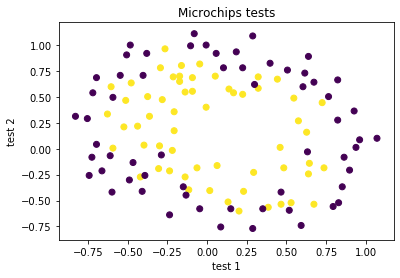

In [ ]:
X1 = X[:,0]
X2 = X[:,1]

# display
fig = plt.figure()
plt.title('Microchips tests')
plt.xlabel('test 1')
plt.ylabel('test 2')
plt.scatter(X1,X2, c=y.ravel())
plt.show()

### Feature mapping
The scatter plot shows that our dataset cannot be separated into positive and negative examples by a straight-line through the plot. Therefore, a straightforward application of logistic regression will not perform well on this dataset since logistic regression will only be able to find a linear decision boundary.

One way to fit the data better is to create more features from each data point. Sklearn provide you with such transformation. PolynomialFeatures allow you to map the features into all polynomial terms of $x_1$ and $x_2$ up to the order power $order$:
$$(1, x_1, x_2, x_1^2, x_2^2, x_1x_2, x_1^3, x_1^2x_2, x_2^2x_1, x_2^3, ..., x_2^{order})$$

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

order = 30

poly = PolynomialFeatures(order)
Xmap = poly.fit_transform(X)

print(X.shape)
print(Xmap.shape)

(118, 2)
(118, 496)


As a result of a six order power mapping (order=6), our vector of two features (the scores on two QA tests) has been transformed into a 28-dimensional vector. A logistic regression classifier trained on this higher-dimension feature vector will have a more complex decision boundary and will appear nonlinear when drawn in our 2-dimensional plot.

### fit a logistic regression model to the polynomial features

In [ ]:
clf = LogisticRegression(random_state=0, solver='lbfgs', multi_class='multinomial', C=10**7).fit(Xmap, y.ravel())
w_star = clf.coef_[0]

/Applications/MiniConda3/envs/mlpylab/lib/python3.6/site-packages/sklearn/linear_model/_logistic.py:940: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG)


### Plot the decision boundary

No handles with labels found to put in legend.


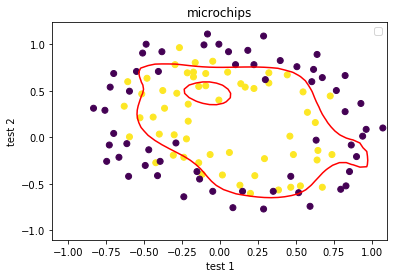

In [ ]:
def get_boundary(u, v, theta, order):
    boundary = np.zeros(shape=(len(u), len(v)))
    for i in range(len(u)):
        for j in range(len(v)):

            poly = PolynomialFeatures(order)
            uv = [np.array([u[i],v[j]])]
            poly_map = poly.fit_transform([np.array([u[i],v[j]])])
            boundary[i, j] = (poly_map[0].dot(np.array(theta)))

    return boundary

#plot data and boundary
fig = plt.figure()

u = np.linspace(-1.1, 1.1, 50)
v = np.linspace(-1.1, 1.1, 50)

boundary = get_boundary(u, v, w_star, order)

plt.title('microchips')
plt.xlabel('test 1')
plt.ylabel('test 2')
plt.scatter(X1,X2, c=y.ravel())
plt.contour(u, v, boundary, 0, colors='red')
plt.legend()
plt.show()

### Evaluating the regularized logistic regression

In [ ]:
clf.score(Xmap, y)

0.8813559322033898

## Tuning the hyper-parameters
Try tuning the two hyper-parameters ($C$ and the polynome order) and see how the decision boundary and the model's accuracy evolve.

### Use a grid search

In [ ]:
acc = np.zeros((10, 20))

C_range = list(10**x for x in range (0, 10))

for idx, c in enumerate(C_range):
    print(idx, sep='.', end='', flush=True)
    for order in range(1,21):
        poly = PolynomialFeatures(order)
        Xmap = poly.fit_transform(X)

        clf = LogisticRegression(random_state=0, solver='lbfgs', multi_class='multinomial', C=c).fit(Xmap, y)

        acc[idx,order-1] = clf.score(Xmap, y)

0

/Applications/MiniConda3/envs/mlpylab/lib/python3.6/site-packages/sklearn/utils/validation.py:760: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Applications/MiniConda3/envs/mlpylab/lib/python3.6/site-packages/sklearn/utils/validation.py:760: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Applications/MiniConda3/envs/mlpylab/lib/python3.6/site-packages/sklearn/utils/validation.py:760: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Applications/MiniConda3/envs/mlpylab/lib/python3.6/site-packages/sklearn/utils/validation.py:760: DataConversionWarning: A column-vecto

1

/Applications/MiniConda3/envs/mlpylab/lib/python3.6/site-packages/sklearn/utils/validation.py:760: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Applications/MiniConda3/envs/mlpylab/lib/python3.6/site-packages/sklearn/utils/validation.py:760: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Applications/MiniConda3/envs/mlpylab/lib/python3.6/site-packages/sklearn/utils/validation.py:760: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Applications/MiniConda3/envs/mlpylab/lib/python3.6/site-packages/sklearn/utils/validation.py:760: DataConversionWarning: A column-vecto

2

...

/Applications/MiniConda3/envs/mlpylab/lib/python3.6/site-packages/sklearn/linear_model/_logistic.py:940: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG)
/Applications/MiniConda3/envs/mlpylab/lib/python3.6/site-packages/sklearn/utils/validation.py:760: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Applications/MiniConda3/envs/mlpylab/lib/python3.6/site-packages/sklearn/linear_model/_logistic.py:940: ConvergenceWarning: lbfgs failed to converge (status=

/Applications/MiniConda3/envs/mlpylab/lib/python3.6/site-packages/sklearn/linear_model/_logistic.py:940: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG)
/Applications/MiniConda3/envs/mlpylab/lib/python3.6/site-packages/sklearn/utils/validation.py:760: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Applications/MiniConda3/envs/mlpylab/lib/python3.6/site-packages/sklearn/linear_model/_logistic.py:940: ConvergenceWarning: lbfgs failed to converge (status=

9

/Applications/MiniConda3/envs/mlpylab/lib/python3.6/site-packages/sklearn/linear_model/_logistic.py:940: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG)
/Applications/MiniConda3/envs/mlpylab/lib/python3.6/site-packages/sklearn/utils/validation.py:760: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Applications/MiniConda3/envs/mlpylab/lib/python3.6/site-packages/sklearn/linear_model/_logistic.py:940: ConvergenceWarning: lbfgs failed to converge (status=

/Applications/MiniConda3/envs/mlpylab/lib/python3.6/site-packages/sklearn/linear_model/_logistic.py:940: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG)
/Applications/MiniConda3/envs/mlpylab/lib/python3.6/site-packages/sklearn/utils/validation.py:760: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Applications/MiniConda3/envs/mlpylab/lib/python3.6/site-packages/sklearn/linear_model/_logistic.py:940: ConvergenceWarning: lbfgs failed to converge (status=

### get  $\lambda^*$ and $order^*$ (those maximizing the accuracy)

(4, 10)
0.8983050847457628
c_star =  10000 , order_star =  10


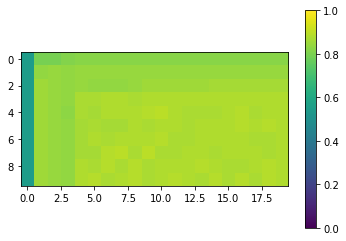

In [ ]:
from numpy import unravel_index
acc_max_idx = unravel_index(acc.argmax(), acc.shape)
print(acc_max_idx)
print(acc[acc_max_idx[0], acc_max_idx[1]])


c_star = C_range[acc_max_idx[0]]
order_star = acc_max_idx[1]

print("c_star = ", c_star, ", order_star = ", order_star)


fig = plt.figure()
fig.clf()
ax = fig.add_subplot(1,1,1)
img = ax.imshow(acc, interpolation='nearest', vmin=0.0, vmax=1.0)
fig.colorbar(img)

plt.show()

### plot data and boundary

/Applications/MiniConda3/envs/mlpylab/lib/python3.6/site-packages/sklearn/utils/validation.py:760: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Applications/MiniConda3/envs/mlpylab/lib/python3.6/site-packages/sklearn/linear_model/_logistic.py:940: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG)
No handles with labels found to put in legend.


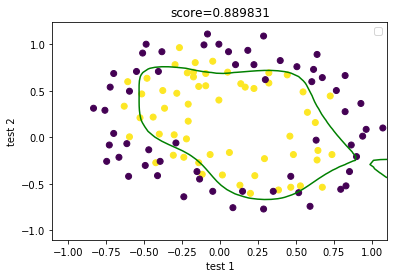

In [ ]:
fig = plt.figure()

u = np.linspace(-1.1, 1.1, 50)
v = np.linspace(-1.1, 1.1, 50)

poly = PolynomialFeatures(order_star)
Xmap = poly.fit_transform(X)
clf = LogisticRegression(random_state=0, solver='lbfgs', multi_class='multinomial', C=c_star).fit(Xmap, y)
theta_star =  clf.coef_[0]


boundary_green = get_boundary(u, v, theta_star, order_star)

plt.title('score=%f' %clf.score(Xmap, y))
plt.xlabel('test 1')
plt.ylabel('test 2')
plt.scatter(X1,X2, c=y.ravel())
plt.contour(u, v, boundary_green, 0, colors='green')
plt.legend()
plt.show()

## Exercise

In [ ]:
#1) use pipelines
#1) try GridSearch and Randomised Search
#2) try SVM with different Kernels
#3) try GridSearch and Randomised Search

  EXERCICE 1 : Utiliser des Pipelines

  Pipeline LR simple:
    Train accuracy = 0.8708
    Test accuracy  = 0.8833

  Pipeline Polynomial (degree=3) + LR:
    Train accuracy = 0.8917
    Test accuracy  = 0.8500


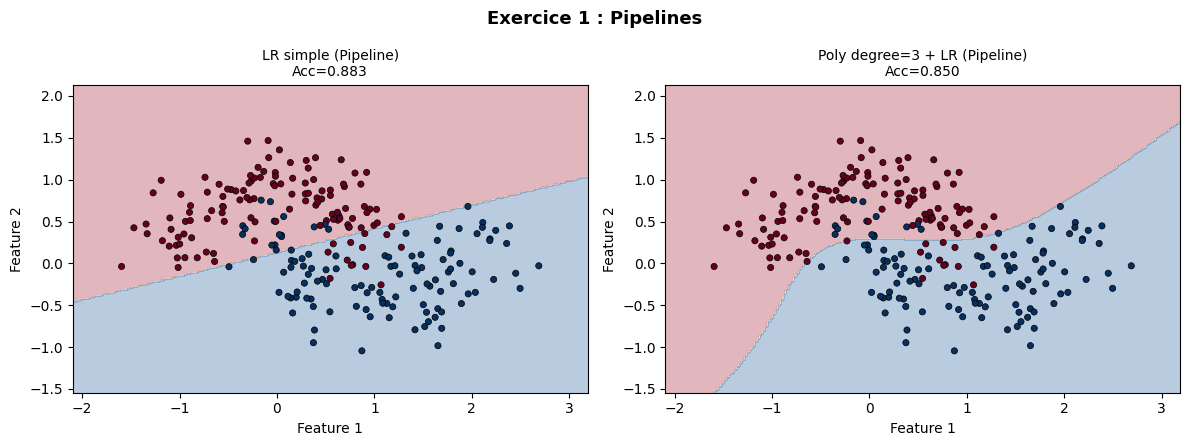


  EXERCICE 2 : GridSearch et RandomizedSearch (Logistic Reg)

  GridSearchCV:
    Best params: {'logreg__C': 100, 'poly__degree': 3}
    Best CV accuracy: 0.9125
    Test accuracy: 0.9167

  RandomizedSearchCV (30 iterations):
    Best params: degree=3, C=15.6095
    Best CV accuracy: 0.9125
    Test accuracy: 0.9000


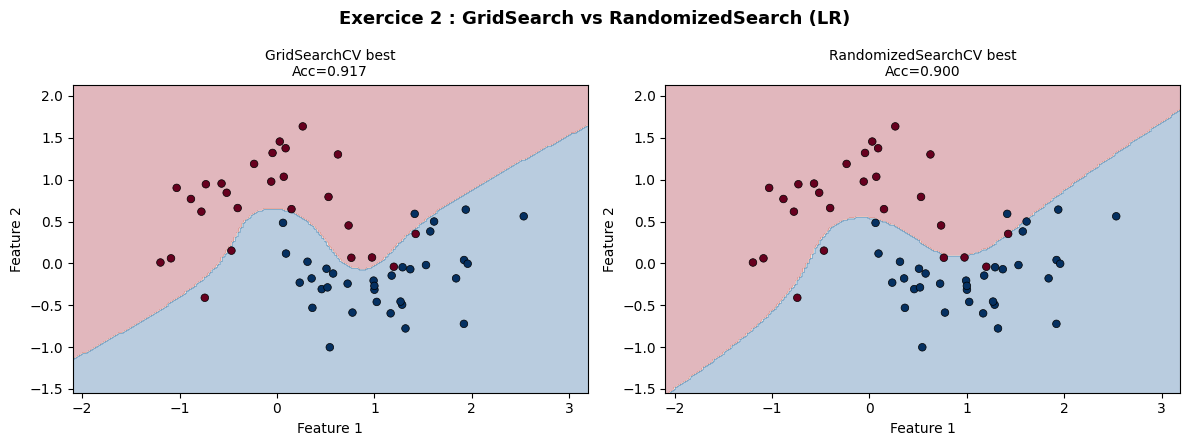


  EXERCICE 3 : SVM avec différents Kernels

  Linear        Train Acc=0.8583  Test Acc=0.8667  Support Vectors=86
  Poly d=3      Train Acc=0.8917  Test Acc=0.8667  Support Vectors=94
  RBF γ=1       Train Acc=0.9167  Test Acc=0.9000  Support Vectors=71
  RBF γ=0.5     Train Acc=0.9125  Test Acc=0.8667  Support Vectors=83


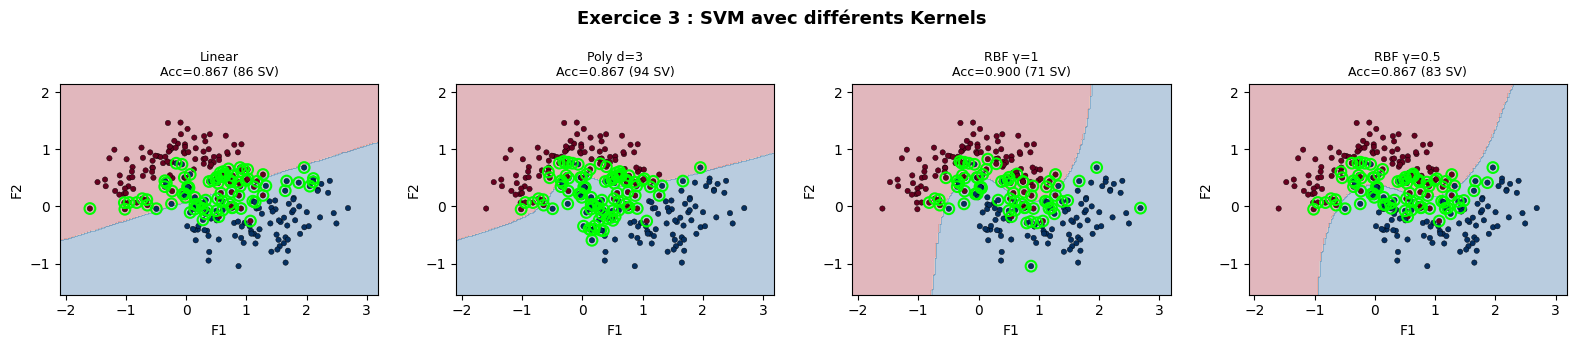


  EXERCICE 4 : GridSearch et RandomizedSearch (SVM)

  GridSearchCV SVM:
    Best params: {'svm__C': 100, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
    Best CV accuracy: 0.9167
    Test accuracy: 0.9333

  RandomizedSearchCV SVM (50 iterations):
    Best params: kernel=rbf, C=92.2874, gamma=0.4525
    Best CV accuracy: 0.9167
    Test accuracy: 0.9333


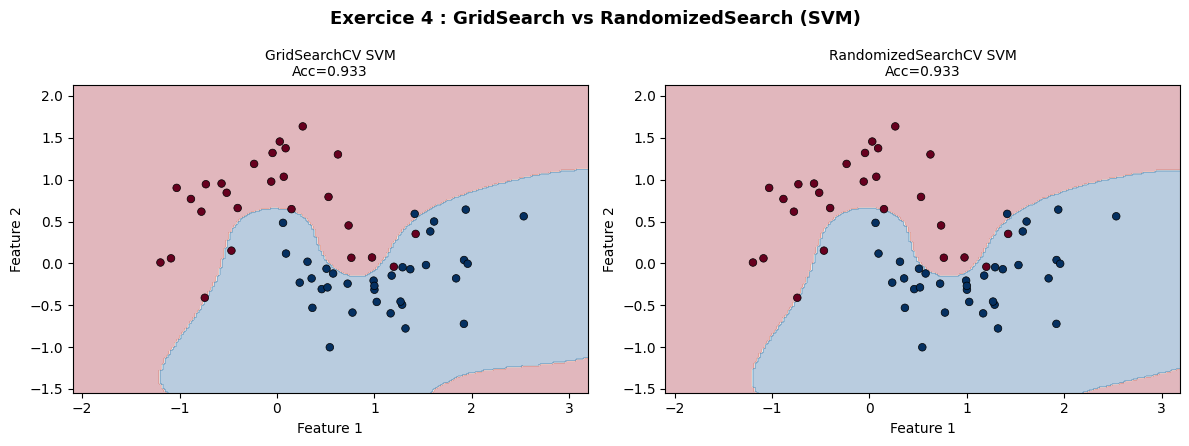


  Classification Report (meilleur SVM):
              precision    recall  f1-score   support

    Classe 0       0.96      0.88      0.92        26
    Classe 1       0.92      0.97      0.94        34

    accuracy                           0.93        60
   macro avg       0.94      0.93      0.93        60
weighted avg       0.93      0.93      0.93        60

  Confusion Matrix:
[[23  3]
 [ 1 33]]


In [2]:
# =============================================================
# EXERCICES - Logistic Regression Lab
# =============================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.datasets import make_moons, make_circles
from scipy.stats import uniform, randint

# --- Générer les données (similaires au notebook) ---
np.random.seed(42)
X_moons, y_moons = make_moons(n_samples=300, noise=0.25, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X_moons, y_moons, test_size=0.2, random_state=42)

print("="*65)
print("  EXERCICE 1 : Utiliser des Pipelines")
print("="*65)

# Pipeline 1 : Logistic Regression simple
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(random_state=42))
])
pipe_lr.fit(X_train, y_train)
print(f"\n  Pipeline LR simple:")
print(f"    Train accuracy = {pipe_lr.score(X_train, y_train):.4f}")
print(f"    Test accuracy  = {pipe_lr.score(X_test, y_test):.4f}")

# Pipeline 2 : Polynomial + Logistic Regression
pipe_poly_lr = Pipeline([
    ('poly', PolynomialFeatures(degree=3, include_bias=False)),
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(C=1.0, max_iter=1000, random_state=42))
])
pipe_poly_lr.fit(X_train, y_train)
print(f"\n  Pipeline Polynomial (degree=3) + LR:")
print(f"    Train accuracy = {pipe_poly_lr.score(X_train, y_train):.4f}")
print(f"    Test accuracy  = {pipe_poly_lr.score(X_test, y_test):.4f}")

# Visualiser les frontières
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for idx, (title, model) in enumerate([
    ("LR simple (Pipeline)", pipe_lr),
    ("Poly degree=3 + LR (Pipeline)", pipe_poly_lr)]):
    ax = axes[idx]
    xx, yy = np.meshgrid(np.linspace(X_moons[:,0].min()-0.5, X_moons[:,0].max()+0.5, 200),
                          np.linspace(X_moons[:,1].min()-0.5, X_moons[:,1].max()+0.5, 200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    ax.scatter(X_train[:,0], X_train[:,1], c=y_train, cmap='RdBu', s=20, edgecolors='k', lw=0.5)
    ax.set_title(f"{title}\nAcc={model.score(X_test,y_test):.3f}", fontsize=10)
    ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')
plt.suptitle("Exercice 1 : Pipelines", fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


print("\n" + "="*65)
print("  EXERCICE 2 : GridSearch et RandomizedSearch (Logistic Reg)")
print("="*65)

# GridSearchCV
pipe_grid = Pipeline([
    ('poly', PolynomialFeatures(include_bias=False)),
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=2000, random_state=42))
])

param_grid = {
    'poly__degree': [1, 2, 3, 4, 5],
    'logreg__C': [0.01, 0.1, 1, 10, 100],
}

grid_search = GridSearchCV(pipe_grid, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"\n  GridSearchCV:")
print(f"    Best params: {grid_search.best_params_}")
print(f"    Best CV accuracy: {grid_search.best_score_:.4f}")
print(f"    Test accuracy: {grid_search.score(X_test, y_test):.4f}")

# RandomizedSearchCV
param_dist = {
    'poly__degree': [1, 2, 3, 4, 5, 6],
    'logreg__C': uniform(0.01, 100),
}

random_search = RandomizedSearchCV(pipe_grid, param_dist, n_iter=30, cv=5,
                                    scoring='accuracy', random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)

print(f"\n  RandomizedSearchCV (30 iterations):")
print(f"    Best params: degree={random_search.best_params_['poly__degree']}, "
      f"C={random_search.best_params_['logreg__C']:.4f}")
print(f"    Best CV accuracy: {random_search.best_score_:.4f}")
print(f"    Test accuracy: {random_search.score(X_test, y_test):.4f}")

# Visualiser le meilleur modèle
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for idx, (title, model) in enumerate([
    ("GridSearchCV best", grid_search.best_estimator_),
    ("RandomizedSearchCV best", random_search.best_estimator_)]):
    ax = axes[idx]
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    ax.scatter(X_test[:,0], X_test[:,1], c=y_test, cmap='RdBu', s=30, edgecolors='k', lw=0.5)
    ax.set_title(f"{title}\nAcc={model.score(X_test,y_test):.3f}", fontsize=10)
    ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')
plt.suptitle("Exercice 2 : GridSearch vs RandomizedSearch (LR)", fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


print("\n" + "="*65)
print("  EXERCICE 3 : SVM avec différents Kernels")
print("="*65)

kernels = [
    ("Linear",  SVC(kernel='linear', C=1.0)),
    ("Poly d=3", SVC(kernel='poly', degree=3, C=1.0)),
    ("RBF γ=1", SVC(kernel='rbf', gamma=1.0, C=1.0)),
    ("RBF γ=0.5", SVC(kernel='rbf', gamma=0.5, C=1.0)),
]

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
print()
for idx, (name, model) in enumerate(kernels):
    model.fit(X_train, y_train)
    tr_acc = model.score(X_train, y_train)
    te_acc = model.score(X_test, y_test)
    print(f"  {name:12s}  Train Acc={tr_acc:.4f}  Test Acc={te_acc:.4f}  "
          f"Support Vectors={model.n_support_.sum()}")

    ax = axes[idx]
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    ax.scatter(X_train[:,0], X_train[:,1], c=y_train, cmap='RdBu', s=15, edgecolors='k', lw=0.3)
    # Marquer les support vectors
    sv = model.support_vectors_
    ax.scatter(sv[:,0], sv[:,1], s=60, facecolors='none', edgecolors='lime', lw=1.5)
    ax.set_title(f"{name}\nAcc={te_acc:.3f} ({model.n_support_.sum()} SV)", fontsize=9)
    ax.set_xlabel('F1'); ax.set_ylabel('F2')

plt.suptitle("Exercice 3 : SVM avec différents Kernels", fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


print("\n" + "="*65)
print("  EXERCICE 4 : GridSearch et RandomizedSearch (SVM)")
print("="*65)

# GridSearchCV pour SVM
pipe_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC())
])

param_grid_svm = {
    'svm__kernel': ['linear', 'poly', 'rbf'],
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 'auto', 0.1, 1],
}

grid_svm = GridSearchCV(pipe_svm, param_grid_svm, cv=5, scoring='accuracy', n_jobs=-1)
grid_svm.fit(X_train, y_train)

print(f"\n  GridSearchCV SVM:")
print(f"    Best params: {grid_svm.best_params_}")
print(f"    Best CV accuracy: {grid_svm.best_score_:.4f}")
print(f"    Test accuracy: {grid_svm.score(X_test, y_test):.4f}")

# RandomizedSearchCV pour SVM
param_dist_svm = {
    'svm__kernel': ['linear', 'poly', 'rbf'],
    'svm__C': uniform(0.1, 100),
    'svm__gamma': uniform(0.01, 5),
}

random_svm = RandomizedSearchCV(pipe_svm, param_dist_svm, n_iter=50, cv=5,
                                 scoring='accuracy', random_state=42, n_jobs=-1)
random_svm.fit(X_train, y_train)

print(f"\n  RandomizedSearchCV SVM (50 iterations):")
print(f"    Best params: kernel={random_svm.best_params_['svm__kernel']}, "
      f"C={random_svm.best_params_['svm__C']:.4f}, "
      f"gamma={random_svm.best_params_['svm__gamma']:.4f}")
print(f"    Best CV accuracy: {random_svm.best_score_:.4f}")
print(f"    Test accuracy: {random_svm.score(X_test, y_test):.4f}")

# Visualiser les meilleurs modèles
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for idx, (title, model) in enumerate([
    ("GridSearchCV SVM", grid_svm.best_estimator_),
    ("RandomizedSearchCV SVM", random_svm.best_estimator_)]):
    ax = axes[idx]
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    ax.scatter(X_test[:,0], X_test[:,1], c=y_test, cmap='RdBu', s=30, edgecolors='k', lw=0.5)
    ax.set_title(f"{title}\nAcc={model.score(X_test,y_test):.3f}", fontsize=10)
    ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')
plt.suptitle("Exercice 4 : GridSearch vs RandomizedSearch (SVM)", fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# Classification report du meilleur modèle
best_model = grid_svm.best_estimator_
y_pred = best_model.predict(X_test)
print(f"\n  Classification Report (meilleur SVM):")
print(classification_report(y_test, y_pred, target_names=['Classe 0', 'Classe 1']))
print(f"  Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

